In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile 
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [4]:
work_dir = os.getcwd()
work_dir

'/workspaces/XrayFractureClass/jupytr_notebooks'

In [5]:
my_data_dir = '/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/val'
test_path = my_data_dir + '/test'
print (train_path)
print(os.path.exists(train_path))

/workspaces/XrayFractureClass/data/raw/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
True


In [6]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


In [7]:
labels = os.listdir(train_path)
print(f"Project Labels: {labels}")

Project Labels: ['fractured', 'not fractured']


In [8]:
import joblib
version = 'v1'
file_path = f'/workspaces/XrayFractureClass/outputs/{version}'
os.makedirs (file_path, exist_ok=True )

image_shape = (224, 224, 3)

joblib.dump(value=image_shape, filename=f'{file_path}/image_shape.pkl')
image_shape = joblib.load(filename=f'{file_path}/image_shape.pkl')
print (f'image_shape : {image_shape}')

image_shape : (224, 224, 3)


* train - fractured: 4606 images
* train - not fractured: 4640 images
* val - fractured: 337 images
* val - not fractured: 492 images
* test - fractured: 238 images
* test - not fractured: 268 images




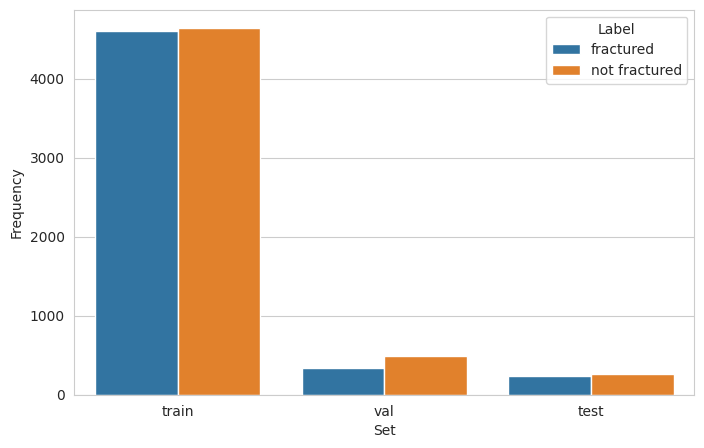

In [9]:
labels = ['fractured', 'not fractured']
file_path = '/workspaces/XrayFractureClass/outputs'
df_freq = pd.DataFrame([])

for folder in ['train', 'val', 'test']:
    for label in labels:
        freq = int(len(os.listdir(my_data_dir + '/' + folder + '/' + label)))
        
        df_freq = pd.concat([df_freq, pd.DataFrame([{'Set': folder, 'Label': label, 'Frequency': freq}])  
        ], ignore_index = True)

        print(
            f"* {folder} - {label}: {len(os.listdir(my_data_dir+'/'+ folder + '/' + label))} images")

print("\n")
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.savefig(f'{file_path}/labels_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
augmented_image_data = ImageDataGenerator(rotation_range=20,
                                          width_shift_range=0.10,
                                          height_shift_range=0.10,
                                          shear_range=0.1,
                                          zoom_range=0.1,
                                          horizontal_flip=True,
                                          vertical_flip=True,
                                          fill_mode='nearest',
                                          rescale=1./255
                                          )

In [12]:
batch_size = 20  # Set batch size
train_set = augmented_image_data.flow_from_directory(train_path,
                                                     target_size=image_shape[:2],
                                                     color_mode='rgb',
                                                     batch_size=batch_size,
                                                     class_mode='binary',
                                                     shuffle=True
                                                     )

train_set.class_indices

Found 9246 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [13]:
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,
                                                                        target_size=image_shape[:2],
                                                                        color_mode='rgb',
                                                                        batch_size=batch_size,
                                                                        class_mode='binary',
                                                                        shuffle=False
                                                                        )

validation_set.class_indices

Found 829 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

In [14]:
test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(test_path,
                                                                  target_size=image_shape[:2],
                                                                  color_mode='rgb',
                                                                  batch_size=batch_size,
                                                                  class_mode='binary',
                                                                  shuffle=False
                                                                  )

test_set.class_indices

Found 506 images belonging to 2 classes.


{'fractured': 0, 'not fractured': 1}

(20, 224, 224, 3)


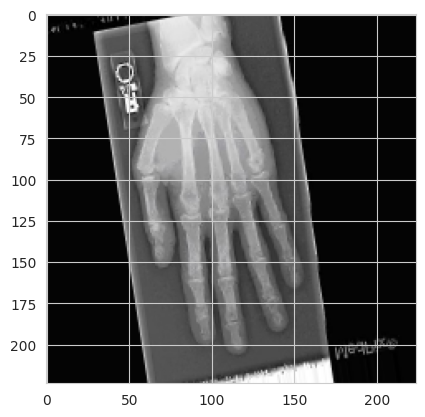

(20, 224, 224, 3)


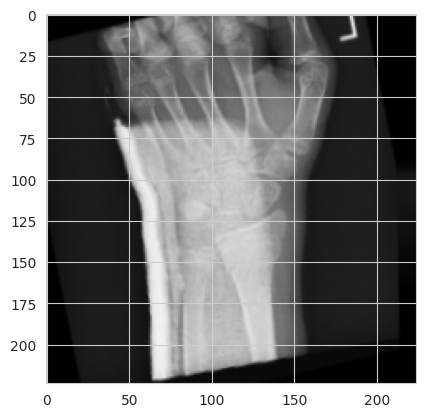

(20, 224, 224, 3)


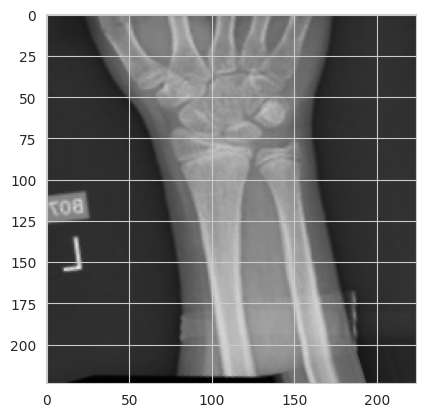

In [15]:
for _ in range(3):
    img, label = next (train_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

(20, 224, 224, 3)


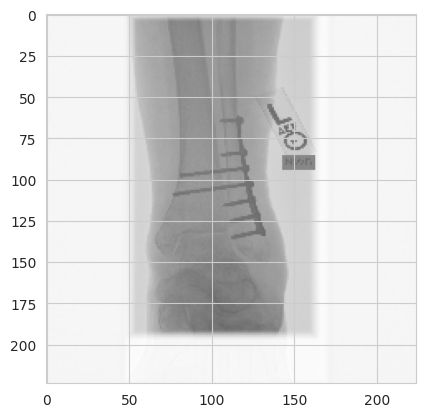

(20, 224, 224, 3)


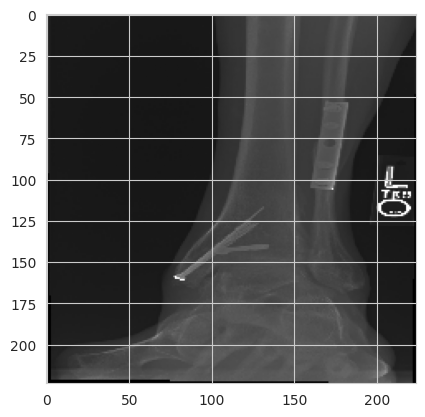

(20, 224, 224, 3)


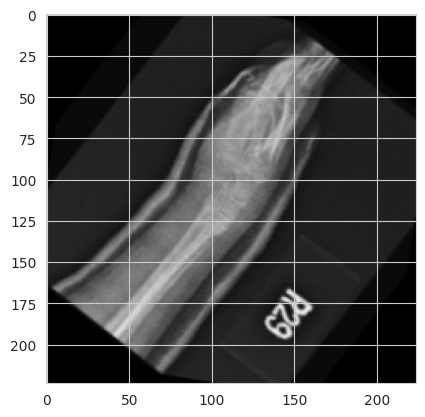

(20, 224, 224, 3)


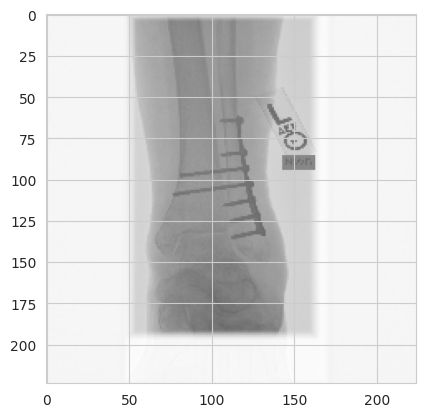

(20, 224, 224, 3)


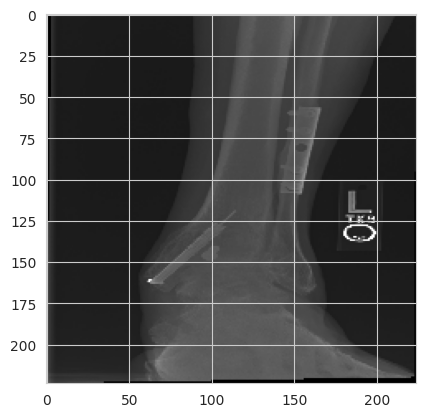

(20, 224, 224, 3)


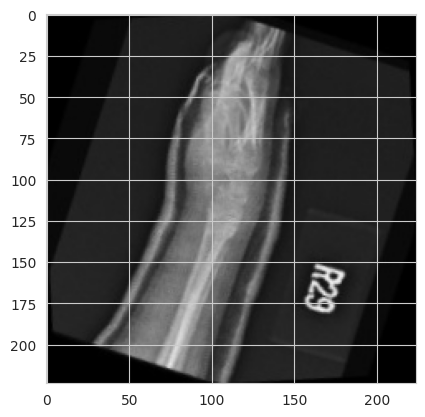

In [16]:
for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()
for _ in range(3):
    img, label = next(test_set)
    print(img.shape)  # (1,256,256,3)
    plt.imshow(img[0])
    plt.show()

In [17]:
joblib.dump(value=train_set.class_indices,
            filename=f"{file_path}/class_indices.pkl")

['/workspaces/XrayFractureClass/outputs/class_indices.pkl']

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [19]:
def create_tf_model():
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3),
              input_shape=image_shape, activation='relu', ))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    return model

In [20]:
create_tf_model().summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779817271.746423    2815 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,369 (21.34 MB)

 Trainable params: 5,594,369 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [22]:
#model = create_tf_model()
#model.fit(train_set,
#          epochs=25,
#          steps_per_epoch=len(train_set.classes) // batch_size,
#          validation_data=validation_set,
#          callbacks=[early_stop],
#          verbose=1
#          )

import tensorflow as tf
model = tf.keras.models.load_model(f'{file_path}/fracture_detection_model_v1.keras')
print('Model loaded successfully')

Model loaded successfully


In [23]:
model.save(f'{file_path}/fracture_detection_model_v1.keras')
print ('The model has been saved')

The model has been saved


In [28]:
#history = pd.DataFrame(model.history.history)
#history.head()

In [29]:
#sns.set_style("whitegrid")
#history[['loss','val_loss']].plot(style='.-')
#plt.title("Loss")
#plt.show()

#print("\n")
#history[['accuracy','val_accuracy']].plot(style='.-')
#plt.title("Accuracy")
#plt.show()

In [30]:
loss, accuracy = model.evaluate(test_set)
print (f'Test Loss = :{loss:.4f}')
print (f'Test Accuracy = :{accuracy:.4f}')

I0000 00:00:1779817434.119380    2815 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step - accuracy: 0.7352 - loss: 0.5405
Test Loss = :0.5405
Test Accuracy = :0.7352


#### Train Set #### 

463/463 ━━━━━━━━━━━━━━━━━━━━ 156s 336ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                  2562                  2044
Predicted not fractured              2598                  2042


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.50      0.56      0.52      4606
not fractured       0.50      0.44      0.47      4640

     accuracy                           0.50      9246
    macro avg       0.50      0.50      0.50      9246
 weighted avg       0.50      0.50      0.50      9246
 



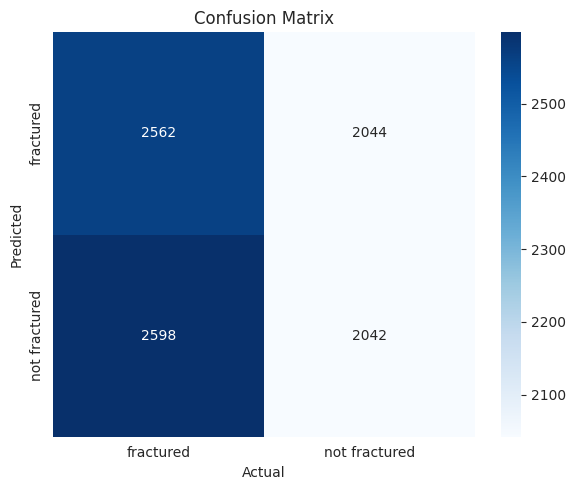

#### Validation Set #### 

13/42 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step

/usr/local/python/3.12.1/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 363ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   277                    60
Predicted not fractured               141                   351


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.66      0.82      0.73       337
not fractured       0.85      0.71      0.78       492

     accuracy                           0.76       829
    macro avg       0.76      0.77      0.76       829
 weighted avg       0.78      0.76      0.76       829
 



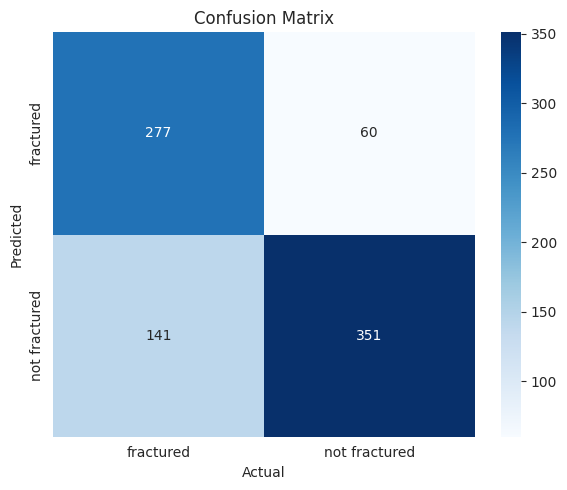

#### Test Set ####

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step
---  Confusion Matrix  ---
                         Actual fractured  Actual not fractured
Predicted fractured                   194                    44
Predicted not fractured                90                   178


---  Classification Report  ---
               precision    recall  f1-score   support

    fractured       0.68      0.82      0.74       238
not fractured       0.80      0.66      0.73       268

     accuracy                           0.74       506
    macro avg       0.74      0.74      0.73       506
 weighted avg       0.75      0.74      0.73       506
 



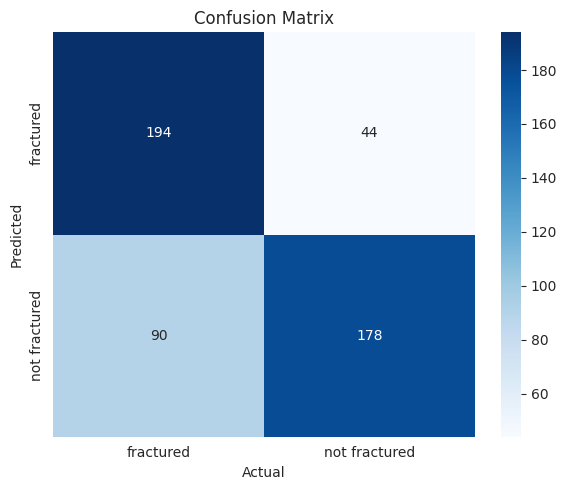

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def confusion_matrix_and_report(data_set, pipeline, label_map):
    data_set.reset()

    prediction = pipeline.predict(data_set)
    prediction = (prediction > 0.5). astype(int).flatten()
    y = data_set.classes

    # Compute confusion matrix
    cm = confusion_matrix(y_true=y, y_pred=prediction)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        cm,
        columns=["Actual " + sub for sub in label_map],
        index=["Predicted " + sub for sub in label_map]))
    
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

    # 🔹 Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_map,
        yticklabels=label_map
    )

    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
def clf_performance(train_set, validation_set, test_set, pipeline, label_map):
  """
  Print classification performance
  """
  print("#### Train Set #### \n")
  confusion_matrix_and_report(train_set, pipeline, label_map)

  print("#### Validation Set #### \n")
  confusion_matrix_and_report(validation_set, pipeline, label_map)

  print("#### Test Set ####\n")
  confusion_matrix_and_report(test_set, pipeline, label_map)

class_names = list(test_set.class_indices.keys())
clf_performance( train_set, validation_set, test_set, model, class_names)